In [1]:
!pip -q install datasets tensorflow

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

from sklearn.model_selection import train_test_split

print("RITHANYA.G")
print("24BAD132")
print("TensorFlow Version:", tf.__version__)

RITHANYA.G
24BAD132
TensorFlow Version: 2.20.0


PART-A

In [3]:
!pip install -U datasets huggingface_hub pyarrow

In [4]:
from datasets import load_dataset
import datasets

print(datasets.__version__)

5.0.1


In [5]:
from datasets import load_dataset

dataset = load_dataset(
    "parquet",
    data_files={
        "train": "hf://datasets/karpathy/tiny_shakespeare@refs/pr/2/data/train-00000-of-00001.parquet",
        "validation": "hf://datasets/karpathy/tiny_shakespeare@refs/pr/2/data/validation-00000-of-00001.parquet",
        "test": "hf://datasets/karpathy/tiny_shakespeare@refs/pr/2/data/test-00000-of-00001.parquet",
    },
)

print(dataset)
print(dataset["train"]["text"][0][:500])

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 1
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 1
    })
    test: Dataset({
        features: ['text'],
        num_rows: 1
    })
})
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [6]:
text = dataset["train"]["text"][0]

# Use only first 50,000 characters
text = text[:50000]

text = text.lower()

print("Characters:", len(text))
print(text[:500])

Characters: 50000
first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor


In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()

tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 2081


In [8]:
input_sequences = []

for line in text.split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i+1])

print("Total Sequences:", len(input_sequences))

Total Sequences: 7489


In [9]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

max_sequence_len = max(len(seq) for seq in input_sequences)

input_sequences = np.array(
    pad_sequences(
        input_sequences,
        maxlen=max_sequence_len,
        padding="pre"
    )
)

print("Shape:", input_sequences.shape)
print("Maximum Sequence Length:", max_sequence_len)

Shape: (7489, 12)
Maximum Sequence Length: 12


In [10]:
X = input_sequences[:, :-1]

y = input_sequences[:, -1]

print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X Shape: (7489, 11)
Y Shape: (7489,)


In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Validation Samples:", X_val.shape[0])

Training Samples: 5991
Validation Samples: 1498


PART-**B**

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential()

# Embedding Layer
model.add(
    Embedding(
        input_dim=total_words,
        output_dim=64,
        input_length=max_sequence_len-1
    )
)

# Simple RNN Layer
model.add(SimpleRNN(128))

# Output Layer
model.add(Dense(total_words, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

PART-**C**

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.0402 - loss: 6.7984 - val_accuracy: 0.0381 - val_loss: 6.6918
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0439 - loss: 6.3310 - val_accuracy: 0.0381 - val_loss: 6.7803
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0474 - loss: 6.2029 - val_accuracy: 0.0421 - val_loss: 6.7746
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.0527 - loss: 6.0257 - val_accuracy: 0.0487 - val_loss: 6.8185
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0584 - loss: 5.8258 - val_accuracy: 0.0454 - val_loss: 6.8240
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0666 - loss: 5.6086 - val_accuracy: 0.0527 - val_loss: 6.8635
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0751 - loss: 5.3952 - val_accuracy: 0.0547 - val_loss: 6.9569
Epoch 8/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0856 - loss: 5.1792 - val_accuracy: 0.0507 - v

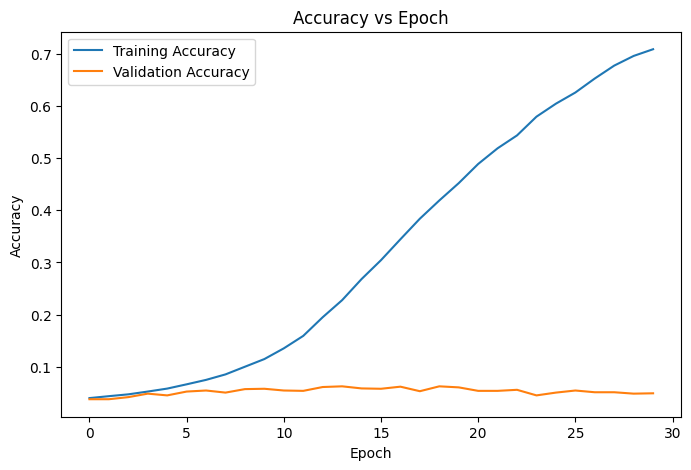

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

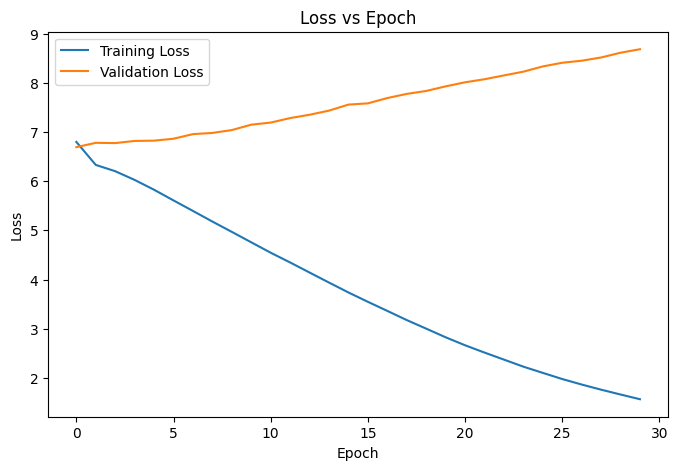

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

PART-**D**

In [17]:
def generate_text(seed_text, next_words):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len-1,
            padding='pre'
        )

        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

In [18]:
print(generate_text("the king", 15))

the king gods assist you are awe news else have done way the city of the neck


In [19]:
print(generate_text("love is", 15))

love is marcius more that i am known to be him follow marcius ne'er more him the


In [20]:
print(generate_text("to be", 15))

to be themselves our youth of smile stored run little to the letter for that you follow
